# UFO-120 Exploration (TURBIDITY CALIBRATION)
**Assigned to:** ___
**No GPU needed.**

Used to CALIBRATE our Jaffe-McGlamery augmentation and for qualitative validation.
**Has NO bounding box labels** — cannot compute mAP.

In [1]:
import os
from pathlib import Path


def resolve_dataset_path():
    candidates = []

    env_path = os.environ.get("UFO120_DATASET")
    if env_path:
        candidates.append(Path(env_path).expanduser())

    workspace_root = Path.cwd()
    candidates.extend(
        [
            workspace_root / "data" / "UFO-120",
            workspace_root / "data" / "ufo-120",
            workspace_root / "datasets" / "UFO-120",
            workspace_root / "datasets" / "ufo-120",
            workspace_root / "UFO-120",
            workspace_root / "ufo-120",
        ]
    )

    try:
        from google.colab import drive

        drive.mount("/content/drive")
        candidates.extend(
            [
                Path("/content/drive/MyDrive/underwater_datasets/UFO-120"),
                Path("/content/drive/MyDrive/underwater_datasets/ufo-120"),
            ]
        )
        drive_root = Path("/content/drive/MyDrive/underwater_datasets")
        if drive_root.exists():
            candidates.extend(
                path
                for path in drive_root.iterdir()
                if path.is_dir() and "ufo" in path.name.lower()
            )
    except Exception:
        pass

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    return None


dataset_path = resolve_dataset_path()
DATASET = str(dataset_path) if dataset_path is not None else ""

if dataset_path is None:
    print("UFO-120 dataset not found. Set UFO120_DATASET or place the dataset in a standard local path.")
else:
    print(f"✓ {dataset_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ /content/drive/.shortcut-targets-by-id/1pFQ7s1dKNcCs8XoAqVko91mM_j2sHVSE/underwater_datasets/UFO-120


In [2]:
from pathlib import Path
from collections import Counter

root = Path(DATASET) if DATASET else None

if root is None or not root.exists():
    print("Dataset path is not set or unavailable; skipping folder scan.")
else:
    for dp, dn, fn in sorted(os.walk(root)):
        depth = str(dp).replace(str(root), "").count(os.sep)
        if depth > 3:
            continue
        indent = "  " * depth
        exts = Counter(Path(f).suffix.lower() for f in fn)
        if exts:
            print(f"{indent}{os.path.basename(dp)}/")
            for e, c in sorted(exts.items()):
                print(f"{indent}  {c:>6} {e}")
        else:
            print(f"{indent}{os.path.basename(dp)}/")


UFO-120/
       1 .txt
  TEST/
    hr/
         120 .jpg
    lrd/
         120 .jpg
    mask/
         120 .jpg
  train_val/
    hr/
        1500 .jpg
           1 .lnk
    lrd/
        1516 .jpg
    mask/
        1500 .jpg


In [3]:
# === FIND CLEAN-TURBID PAIRS ===
from pathlib import Path
from collections import defaultdict

root = Path(DATASET) if DATASET else None
folders = defaultdict(list)

if root is None or not root.exists():
    print("Dataset path is not set or unavailable; skipping folder discovery.")
else:
    for img in root.rglob("*"):
        if img.suffix.lower() in {".jpg", ".png", ".bmp", ".jpeg"}:
            folders[str(img.parent.relative_to(root))].append(img)

    print("Image folders:")
    for f in sorted(folders):
        print(f"  {f}: {len(folders[f])} images")
    print("\nIdentify which folders are CLEAN vs TURBID pairs for calibration.")


Image folders:
  TEST/hr: 120 images
  TEST/lrd: 120 images
  TEST/mask: 120 images
  train_val/hr: 1500 images
  train_val/lrd: 1516 images
  train_val/mask: 1500 images

Identify which folders are CLEAN vs TURBID pairs for calibration.


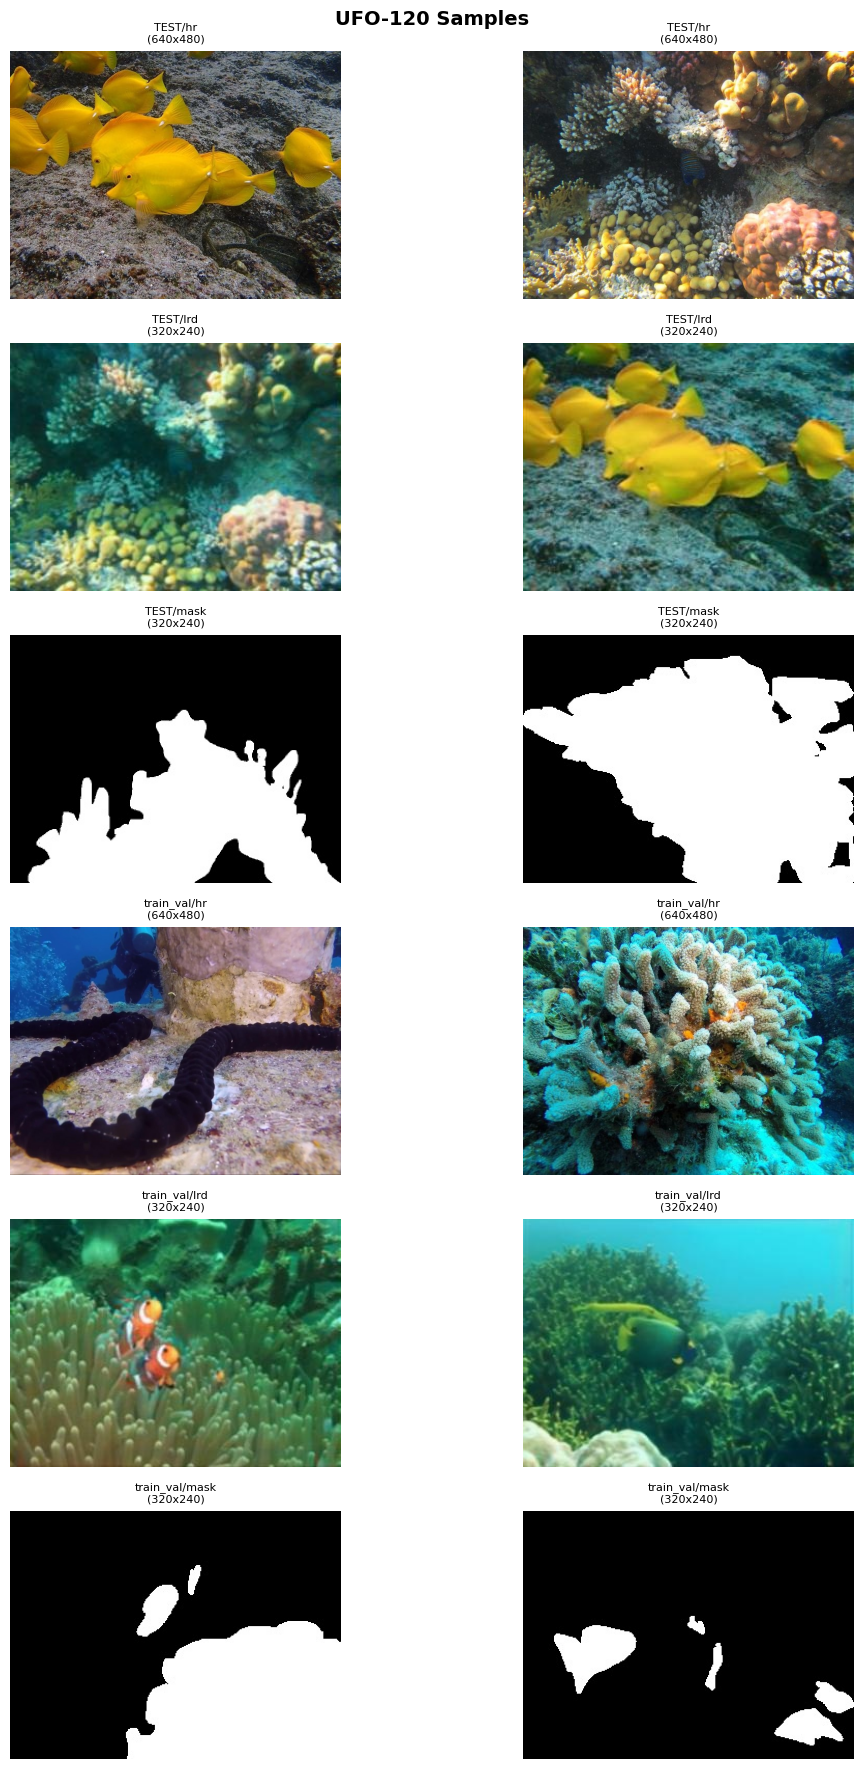

In [4]:
# === SAMPLE IMAGES FROM EACH FOLDER ===
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

root = Path(DATASET) if DATASET else None
folders = defaultdict(list)

if root is None or not root.exists():
    print("Dataset path is not set or unavailable; skipping image sampling.")
    flist = []
    n = 0
else:
    for img in root.rglob("*"):
        if img.suffix.lower() in {".jpg", ".png", ".bmp", ".jpeg"}:
            folders[str(img.parent.relative_to(root))].append(img)

    flist = sorted(folders.keys())[:8]
    n = len(flist)
    if n == 0:
        print("No images!")
    else:
        fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n))
        if n == 1:
            axes = axes.reshape(1, -1)
        for r, f in enumerate(flist):
            for c in range(min(2, len(folders[f]))):
                ax = axes[r][c]
                img = cv2.imread(str(folders[f][c]))
                if img is not None:
                    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                    h, w = img.shape[:2]
                    ax.set_title(f"{f}\n({w}x{h})", fontsize=8)
                ax.axis("off")
        plt.suptitle("UFO-120 Samples", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig("/content/ufo120_samples.png", dpi=150, bbox_inches="tight")
        plt.show()


In [ ]:
# === PSNR/SSIM (uncomment after identifying pairs) ===
# Run this cell ONLY after updating CLEAN and TURBID paths below with actual folder names.

if not DATASET:
    print("Dataset path is not set; PSNR/SSIM comparison is skipped.")
else:
    try:
        # Commented out by default — uncomment and set correct paths to use
        # !pip install -q scikit-image
        # from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
        # import cv2, numpy as np
        # from pathlib import Path
        # root = Path(DATASET)
        #
        # CLEAN = root / "train_val/hr"    # ← UPDATE with actual folder
        # TURBID = root / "train_val/lrd"  # ← UPDATE with actual folder
        #
        # psnr_v, ssim_v = [], []
        # for cf in sorted(CLEAN.glob("*"))[:50]:
        #     tf = TURBID / cf.name
        #     if not tf.exists(): continue
        #     c = cv2.imread(str(cf)); t = cv2.imread(str(tf))
        #     if c is None or t is None: continue
        #     if c.shape != t.shape: t = cv2.resize(t, (c.shape[1],c.shape[0]))
        #     psnr_v.append(psnr(c,t)); ssim_v.append(ssim(c,t,channel_axis=2))
        #
        # print(f"PSNR: {np.mean(psnr_v):.2f} ± {np.std(psnr_v):.2f}")
        # print(f"SSIM: {np.mean(ssim_v):.4f} ± {np.std(ssim_v):.4f}")
        
        print("PSNR/SSIM analysis — uncomment code above and set CLEAN/TURBID folder paths to run.")
    except Exception as e:
        print(f"Error in PSNR/SSIM cell: {e}")


PSNR/SSIM analysis — uncomment code above and set CLEAN/TURBID folder paths to run.


In [ ]:
total_images = sum(len(v) for v in folders.values()) if "folders" in globals() else 0
folder_count = len(folders) if "folders" in globals() else 0

print(
    f'''
================================================================
UFO-120 SUMMARY
================================================================
1. Total images: {total_images}
2. Clean-turbid pairs exist? Manual identification needed
3. Clean folder: ___
4. Turbid folder: ___
5. PSNR: ___ ± ___
6. SSIM: ___ ± ___
7. Has bbox annotations: NO
8. Usable for mAP: NO
9. Usable for calibration: {'YES' if total_images > 0 else 'NO'}
10. Usable for qualitative: {'YES' if total_images > 0 else 'NO'}
11. Folder count: {folder_count}
================================================================
'''
)



UFO-120 SUMMARY
1. Total images: 4876
2. Clean-turbid pairs exist? Manual identification needed
3. Clean folder: ___
4. Turbid folder: ___
5. PSNR: ___ ± ___
6. SSIM: ___ ± ___
7. Has bbox annotations: NO
8. Usable for mAP: NO
9. Usable for calibration: YES
10. Usable for qualitative: YES
11. Folder count: 6



In [7]:
# === EXPORT SUMMARY FOR PAPER TABLES ===
import csv
import json
import os
from datetime import datetime, timezone
from pathlib import Path


def find_results_tables_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]

    if DATASET:
        ds = Path(DATASET)
        candidates.extend([ds, *ds.parents])

    for base in candidates:
        target = base / "results" / "tables"
        if target.exists():
            return target

    return Path.cwd() / "results" / "tables"


root = Path(DATASET) if DATASET else None
folders_local = {}
img_exts = {".jpg", ".jpeg", ".png", ".bmp"}

if root is not None and root.exists():
    for img in root.rglob("*"):
        if img.suffix.lower() in img_exts:
            key = str(img.parent.relative_to(root))
            folders_local.setdefault(key, []).append(img)

total_images = sum(len(v) for v in folders_local.values()) if folders_local else 0
folder_count = len(folders_local)

summary = {
    "dataset": "UFO-120",
    "dataset_path": str(root) if root is not None and root.exists() else "N/A",
    "total_images": total_images if total_images > 0 else "N/A",
    "clean_turbid_pairs": "Manual identification needed",
    "clean_folder": "___",
    "turbid_folder": "___",
    "psnr": "___ ± ___",
    "ssim": "___ ± ___",
    "has_bbox_annotations": "NO",
    "usable_for_map": "NO",
    "usable_for_calibration": "YES" if total_images > 0 else "NO",
    "usable_for_qualitative": "YES" if total_images > 0 else "NO",
    "folder_count": folder_count,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}

out_dir = find_results_tables_dir()
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = out_dir / "ufo120_summary.csv"
json_path = out_dir / "ufo120_summary.json"

with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
    writer.writeheader()
    writer.writerow(summary)

json_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"Saved CSV: {csv_path}")
print(f"Saved JSON: {json_path}")
print("Exported summary:")
print(json.dumps(summary, indent=2))

Saved CSV: /content/results/tables/ufo120_summary.csv
Saved JSON: /content/results/tables/ufo120_summary.json
Exported summary:
{
  "dataset": "UFO-120",
  "dataset_path": "/content/drive/.shortcut-targets-by-id/1pFQ7s1dKNcCs8XoAqVko91mM_j2sHVSE/underwater_datasets/UFO-120",
  "total_images": 4876,
  "clean_turbid_pairs": "Manual identification needed",
  "clean_folder": "___",
  "turbid_folder": "___",
  "psnr": "___ \u00b1 ___",
  "ssim": "___ \u00b1 ___",
  "has_bbox_annotations": "NO",
  "usable_for_map": "NO",
  "usable_for_calibration": "YES",
  "usable_for_qualitative": "YES",
  "folder_count": 6,
  "generated_at_utc": "2026-04-12T15:32:32.940379+00:00"
}
